<a href="https://colab.research.google.com/github/DymaStar/DTA_2026/blob/main/ML/DS_220626_%22ML2_DTA_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

# ---------- Датасет: ВІДТІК (класифікація) ----------
m = 1500
tenure  = np.random.randint(1, 72, m)
monthly = np.random.normal(70, 25, m).clip(15, 150)
support = np.random.poisson(1.5, m)
age     = np.random.randint(18, 75, m)
contract = np.random.choice(["місячний", "річний", "дворічний"], m, p=[.5, .3, .2])
contract_risk = pd.Series({"місячний": .8, "річний": -.3, "дворічний": -.8})

risk = (-0.05*tenure + 0.02*monthly + 0.45*support - 0.01*age
        + contract_risk[contract].values + np.random.normal(0, .7, m))
prob = 1/(1+np.exp(-(risk-0.5)))
churn = (np.random.rand(m) < prob).astype(int)

cust = pd.DataFrame({
    "tenure": tenure, "monthly": monthly.round(1), "support": support,
    "age": age, "contract": contract, "churn": churn,
})

print("Частка відтоку:", f"{cust['churn'].mean():.1%}")

Частка відтоку: 43.2%


In [22]:
cust

,tenure,monthly,support,age,contract,churn
0,52,82.1,2,42,дворічний,1
1,15,59.5,5,69,дворічний,1
2,61,98.3,3,71,річний,0
3,21,63.1,0,41,місячний,1
4,24,104.6,5,74,місячний,1
...,...,...,...,...,...,...
1495,28,104.6,5,42,річний,1
1496,35,68.9,2,73,місячний,0
1497,61,118.3,0,48,річний,0
1498,54,67.5,3,54,місячний,0


## Масштабування числових ознак

У цьому блоці ми перевіряємо числові ознаки `age`, `monthly` та `tenure`.

Мета: побачити, що ці ознаки мають різні діапазони значень.  
Наприклад, `monthly` може бути значно більшим за `tenure`, тому модель може неправильно надавати йому більшу вагу.

Перед навчанням моделей машинного навчання такі ознаки часто потрібно масштабувати.

In [23]:
# Імпортуємо інструменти для масштабування даних
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Беремо тільки числові колонки, які будемо масштабувати
sample = cust[['age', 'monthly', 'tenure']].copy()

# Виводимо статистику ДО масштабування
print("До масштабування (різні діапазони):")

# describe() рахує статистику, а loc залишає тільки mean, min, max
sample.describe().loc[['mean', 'min', 'max', 'std']].round(1)

До масштабування (різні діапазони):


,age,monthly,tenure
mean,45.6,70.9,35.4
min,18.0,15.0,1.0
max,74.0,150.0,71.0
std,16.4,25.7,20.5


## Масштабування даних за допомогою StandardScaler

У цьому блоці використовується **StandardScaler** для стандартизації числових ознак.

Після такого масштабування:
- середнє значення кожної ознаки стає приблизно **0**;
- стандартне відхилення стає приблизно **1**.

Таке масштабування особливо корисне для моделей, які залежать від відстаней або величини ознак, наприклад:
- Logistic Regression;
- KNN;
- SVM;
- PCA;
- Neural Networks.

In [24]:
# Створюємо об'єкт StandardScaler
scaler = StandardScaler()

# Масштабуємо дані та зберігаємо результат у DataFrame
scaled = pd.DataFrame(
    scaler.fit_transform(sample),
    columns=sample.columns
)

# Виводимо основні статистики після масштабування
print("Після StandardScaler (середнє≈0, std≈1, усі ознаки в одному масштабі)")

scaled.describe().loc[['mean', 'min', 'max', 'std']].round(2)

Після StandardScaler (середнє≈0, std≈1, усі ознаки в одному масштабі)


,age,monthly,tenure
mean,0.00,0.00,0.00
min,-1.68,-2.18,-1.68
max,1.73,3.08,1.73
std,1.00,1.00,1.00


### Висновок

Після застосування **StandardScaler** всі числові ознаки були стандартизовані.

Результати підтверджують правильне масштабування:
- **mean ≈ 0** — середнє значення кожної ознаки стало близьким до нуля;
- **std ≈ 1** — стандартне відхилення кожної ознаки стало рівним одиниці;
- **min** та **max** показують, наскільки найменші та найбільші значення відхиляються від середнього у стандартних відхиленнях.

Після такого перетворення всі ознаки знаходяться в однаковому масштабі, що покращує роботу багатьох алгоритмів машинного навчання.

### Як працює StandardScaler

StandardScaler не приводить значення до діапазону від 0 до 1.

Він виконує стандартизацію за формулою:

z = (x - mean) / std

де:
- x — початкове значення;
- mean — середнє значення ознаки;
- std — стандартне відхилення.

Після стандартизації:
- середнє значення кожної ознаки дорівнює приблизно 0;
- стандартне відхилення дорівнює приблизно 1.

Таким чином:
- значення, що дорівнює середньому, стане 0;
- значення вище середнього буде додатним;
- значення нижче середнього буде від'ємним.

Наприклад, якщо вік знаходиться майже на одне стандартне відхилення нижче середнього, після масштабування він стане приблизно -1. Якщо майже на одне стандартне відхилення вище — приблизно +1.

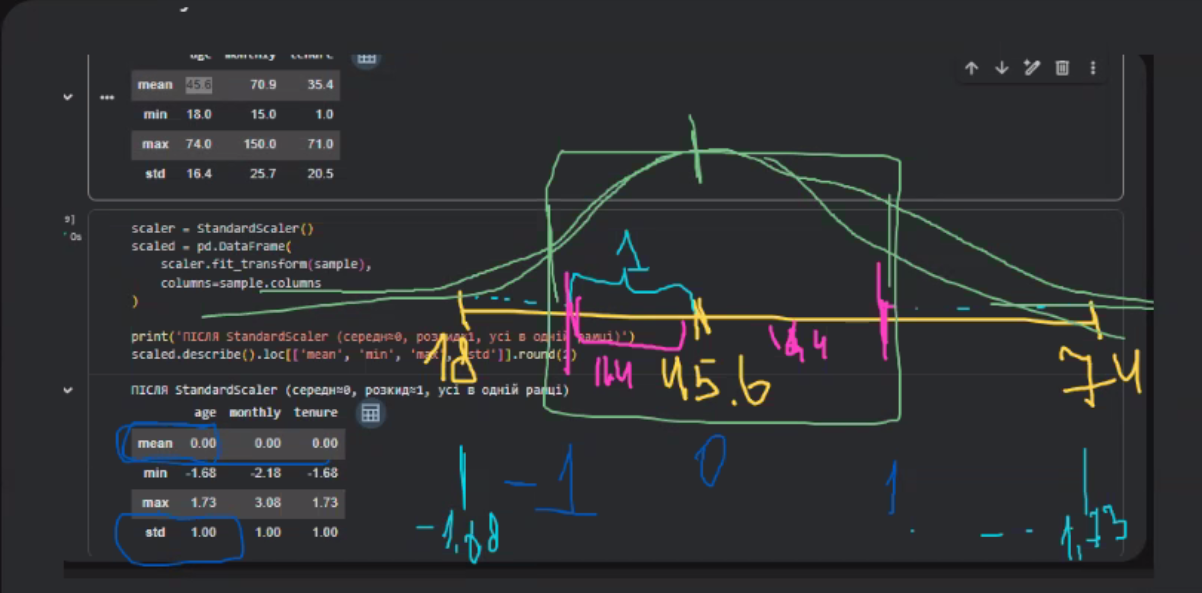

### Висновок

Після застосування StandardScaler всі ознаки мають однаковий масштаб:
- mean ≈ 0;
- std ≈ 1.

Саме тому у таблиці з'являються значення приблизно від -2 до +3 замість початкових років, місяців або грошових сум.

## Масштабування даних за допомогою MinMaxScaler

У цьому прикладі використовується **MinMaxScaler**, який масштабує всі значення до заданого діапазону.

За замовчуванням діапазон становить **від 0 до 1**.

При цьому:
- мінімальне значення кожної ознаки перетворюється на **0**;
- максимальне значення — на **1**;
- усі інші значення пропорційно розташовуються між ними.

Після масштабування перевіримо статистичні характеристики: **mean**, **min**, **max** та **std**.

In [25]:
# Створюємо об'єкт MinMaxScaler
scaler_min_max = MinMaxScaler()

# Масштабуємо дані до діапазону [0;1]
scaled_min_max = pd.DataFrame(
    scaler_min_max.fit_transform(sample),
    columns=sample.columns
)

# Виводимо статистику після масштабування
print("Після MinMaxScaler (усі значення знаходяться в діапазоні від 0 до 1)")

scaled_min_max.describe().loc[['mean', 'min', 'max', 'std']].round(2)

Після MinMaxScaler (усі значення знаходяться в діапазоні від 0 до 1)


,age,monthly,tenure
mean,0.49,0.41,0.49
min,0.00,0.00,0.00
max,1.00,1.00,1.00
std,0.29,0.19,0.29


### Висновок

Після застосування **MinMaxScaler** усі ознаки були масштабовані до діапазону **від 0 до 1**.

Результати підтверджують правильність масштабування:
- **min = 0** — мінімальне значення кожної ознаки стало 0;
- **max = 1** — максимальне значення стало 1;
- **mean** показує середнє значення після масштабування;
- **std** характеризує розкид значень у новому масштабі.

На відміну від **StandardScaler**, MinMaxScaler не центрує дані навколо нуля, а лише змінює їхній масштаб, зберігаючи відносні відстані між значеннями.

## Методи fit(), transform() та fit_transform()

Під час підготовки даних часто використовуються три основні методи:

### fit()

Метод **fit()** навчає перетворювач на тренувальних даних.

Наприклад, для StandardScaler він обчислює:
- середнє значення (mean);
- стандартне відхилення (std).

Для MinMaxScaler:
- мінімальне значення;
- максимальне значення.

> Метод **fit()** викликається лише на тренувальних даних (`X_train`).

---

### transform()

Метод **transform()** застосовує вже обчислені параметри до даних.

Його використовують як для тренувальної, так і для тестової вибірки:

- `transform(X_train)`
- `transform(X_test)`

При цьому жодного повторного навчання не відбувається.

---

### fit_transform()

Метод **fit_transform()** поєднує дві операції:

1. Навчання (`fit`);
2. Перетворення (`transform`).

Його зручно використовувати, коли потрібно одразу навчити перетворювач і застосувати його до одного набору даних.

### Висновок

При роботі з навчальною та тестовою вибірками потрібно дотримуватись правильної послідовності:

1. `fit()` — тільки на тренувальних даних.
2. `transform()` — окремо для тренувальної та тестової вибірки.
3. `fit_transform()` — використовують лише тоді, коли навчання і перетворення виконуються одночасно для одного набору даних.

Такий підхід запобігає витоку інформації (data leakage) з тестових даних у процес навчання моделі.

# Pipelines

## Підготовка даних до машинного навчання

Перед навчанням моделі необхідно підготувати дані.

У нашому наборі є:
- числові ознаки (`tenure`, `monthly`, `support`, `age`);
- категоріальна ознака (`contract`);
- цільова змінна (`churn`).

Для автоматизації всіх етапів підготовки використовується **Pipeline**, який дозволяє об'єднати кілька операцій в один послідовний процес.

In [26]:
cust.columns

Index(['tenure', 'monthly', 'support', 'age', 'contract', 'churn'], dtype='object')

## Імпорт необхідних інструментів

Для побудови конвеєра обробки даних імпортуємо:

- **Pipeline** — створює послідовність кроків обробки;
- **ColumnTransformer** — дозволяє застосовувати різні перетворення до різних стовпців;
- **StandardScaler** — стандартизує числові ознаки;
- **OneHotEncoder** — перетворює категоріальні ознаки у числовий формат.

## Побудова Pipeline для класифікації клієнтів

У цьому блоці створюється повний Pipeline для прогнозування відтоку клієнтів (`churn`).

Pipeline складається з двох основних частин:

1. **Попередня обробка даних (`prep`)**
   - числові ознаки масштабуються через `StandardScaler`;
   - категоріальна ознака `contract` кодується через `OneHotEncoder`.

2. **Модель (`model`)**
   - використовується `LogisticRegression`;
   - параметр `max_iter=1000` збільшує кількість ітерацій, щоб модель краще сходилася під час навчання.

Далі дані будуть розділені на тренувальну та тестову вибірки.

In [27]:
# Імпортуємо інструменти для створення Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Імпортуємо інструменти для обробки даних
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Імпортуємо модель логістичної регресії
from sklearn.linear_model import LogisticRegression

# Імпортуємо інструменти для розділення даних і перевірки якості моделі
from sklearn.model_selection import train_test_split, cross_val_score


# X — ознаки, за якими модель буде робити прогноз
X = cust[['tenure', 'monthly', 'support', 'age', 'contract']]

# y — цільова змінна, яку модель повинна передбачити
y = cust['churn']


# Числові колонки
num_cols = ['tenure', 'monthly', 'support', 'age']

# Категоріальні колонки
cat_cols = ['contract']


# Створюємо блок попередньої обробки даних
preprocess = ColumnTransformer([
    # Масштабуємо числові ознаки
    ('num', StandardScaler(), num_cols),

    # Кодуємо категоріальну ознаку contract
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])


# Створюємо повний Pipeline
pipe = Pipeline([
    # Крок 1: підготовка даних
    ('prep', preprocess),

    # Крок 2: модель класифікації
    ('model', LogisticRegression(max_iter=1000))
])

### Висновок

Було створено **ColumnTransformer**, який автоматизує попередню обробку даних.

Він виконує два незалежні перетворення:
- для числових ознак застосовується **StandardScaler**;
- для категоріальних ознак використовується **OneHotEncoder**.

Такий підхід дозволяє одночасно коректно обробляти різні типи даних та використовувати їх для навчання моделей машинного навчання.

## Навчання та оцінка моделі

Перед навчанням моделі дані розділяються на дві частини:

- **тренувальна вибірка (80%)** — використовується для навчання моделі;
- **тестова вибірка (20%)** — використовується для перевірки якості моделі.

Після розділення Pipeline навчається на тренувальних даних, а потім оцінюється на тестовій вибірці за метрикою **Accuracy** (частка правильних прогнозів).

In [28]:
# Розділяємо дані на тренувальну та тестову вибірки
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,          # 20% даних для тестування
    random_state=RANDOM_STATE,  # Фіксуємо випадковість для відтворюваності результатів
    stratify=y              # Зберігаємо однакове співвідношення класів
)

# Навчаємо Pipeline на тренувальній вибірці
pipe.fit(X_train, y_train)

# Оцінюємо точність моделі на тестових даних
print(
    "Accuracy на тесті:",
    round(pipe.score(X_test, y_test), 3)
)

Accuracy на тесті: 0.74


### Висновок

Дані були успішно розділені на тренувальну та тестову вибірки.

Pipeline автоматично:
1. масштабував числові ознаки;
2. закодував категоріальні ознаки;
3. навчив модель Logistic Regression;
4. оцінив її якість на тестових даних.

Отримане значення **Accuracy** показує частку правильних прогнозів моделі на тестовій вибірці.

## Оцінка моделі за допомогою 5-кратної крос-валідації

Для більш надійної оцінки моделі використовується **5-fold Cross Validation**.

Принцип роботи:
- набір даних ділиться на 5 приблизно однакових частин;
- модель навчається 5 разів;
- кожного разу одна частина використовується для перевірки, а решта — для навчання.

У результаті отримуємо:
- Accuracy для кожного розбиття;
- середню Accuracy;
- стандартне відхилення (Std), яке показує стабільність роботи моделі.

In [29]:
# Оцінюємо модель за допомогою 5-кратної крос-валідації
cv = cross_val_score(
    pipe,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

# Виводимо Accuracy для кожного fold,
# середню точність та стандартне відхилення
print(
    f"CV accuracy: {np.round(cv, 3)} | "
    f"середнє: {cv.mean():.3f} ± {cv.std():.3f}"
)

CV accuracy: [0.767 0.747 0.683 0.74  0.747] | середнє: 0.737 ± 0.028


### Висновок

Для оцінки якості моделі було використано **5-кратну крос-валідацію (5-fold Cross Validation)**.

Отримані значення Accuracy для кожного розбиття:

- 0.767
- 0.747
- 0.683
- 0.740
- 0.747

Середня точність моделі становить **0.737 (73.7%)**, а стандартне відхилення — **0.028**.

Невелике значення стандартного відхилення свідчить, що результати моделі є досить стабільними на різних підмножинах даних. Водночас нижче значення Accuracy на третьому розбитті (0.683) показує, що якість моделі може дещо змінюватися залежно від складу навчальної та тестової вибірок.

Загалом крос-валідація підтвердила, що модель Logistic Regression забезпечує стабільну якість прогнозування із середньою точністю близько **74%** і добре узагальнює дані.

## Прогноз для нового клієнта

Після навчання моделі можна використати її для прогнозування поведінки нового клієнта.

Для цього створюється новий запис (`DataFrame`) з такими самими ознаками, які використовувалися під час навчання моделі:

- `tenure` — тривалість користування послугами;
- `monthly` — щомісячний платіж;
- `support` — кількість звернень до служби підтримки;
- `age` — вік клієнта;
- `contract` — тип контракту.

Після цього модель автоматично виконає всі необхідні перетворення через Pipeline та зробить прогноз.

In [30]:
# Створюємо нового клієнта для прогнозування
new_client = pd.DataFrame([{
    'tenure': 40,
    'monthly': 80.5,
    'support': 5,
    'age': 30,
    'contract': 'дворічний'
}])

# Виводимо дані нового клієнта
display(new_client)

# Робимо прогноз
prediction = pipe.predict(new_client)[0]

# Виводимо результат
print(
    "Клієнт -",
    "ПІДЕ" if prediction == 1 else "залишиться"
)

,tenure,monthly,support,age,contract
0,40,80.5,5,30,дворічний


Клієнт - ПІДЕ


### Висновок

Було створено нового клієнта та виконано прогноз за допомогою навченої моделі.

Pipeline автоматично:
1. масштабував числові ознаки;
2. закодував категоріальну ознаку;
3. передав підготовлені дані моделі Logistic Regression;
4. отримав прогноз.

У цьому прикладі модель передбачила, що **клієнт піде**.

## Прогнозування для нових клієнтів

Після навчання Pipeline модель можна використовувати для прогнозування нових клієнтів.

У цьому прикладі порівнюються два клієнти з однаковими числовими характеристиками, але різними типами контракту.

Особливу увагу приділено параметру `handle_unknown='ignore'` у `OneHotEncoder`, який дозволяє моделі працювати навіть тоді, коли під час прогнозування зустрічається категорія, якої не було у навчальному наборі даних.

In [31]:
# ----------------------------------------------------------
# Порівняння прогнозу для різних типів контракту
# ----------------------------------------------------------

clients = pd.DataFrame([
    {
        # Контракт "трирічний" відсутній у навчальному наборі.
        # OneHotEncoder(handle_unknown='ignore')
        # проігнорує цю категорію без помилки.
        'tenure': 40,
        'monthly': 50,
        'support': 5,
        'age': 30,
        'contract': 'трирічний'
    },
    {
        # Контракт "дворічний" був у навчальних даних,
        # тому модель використає цю інформацію під час прогнозу.
        'tenure': 40,
        'monthly': 50,
        'support': 5,
        'age': 30,
        'contract': 'дворічний'
    }
])

# Переглядаємо нових клієнтів
display(clients)

# Отримуємо прогноз для кожного клієнта
predictions = pipe.predict(clients)

# Виводимо результати
for i, pred in enumerate(predictions):
    print(
        f"Клієнт {i+1} ({clients.loc[i, 'contract']}):",
        "ПІДЕ" if pred == 1 else "залишиться"
    )

,tenure,monthly,support,age,contract
0,40,50,5,30,трирічний
1,40,50,5,30,дворічний


Клієнт 1 (трирічний): ПІДЕ
Клієнт 2 (дворічний): залишиться


### Висновок

Було порівняно прогнози моделі для двох клієнтів із однаковими характеристиками, але різними типами контракту.

- Для контракту **«трирічний»** категорія відсутня у навчальному наборі даних. Завдяки параметру `handle_unknown='ignore'` вона не викликає помилку, а просто ігнорується під час кодування. Прогноз у цьому випадку будується на основі інших ознак клієнта.

- Для контракту **«дворічний»** категорія була присутня під час навчання моделі, тому OneHotEncoder коректно її кодує, і модель використовує цю інформацію під час прогнозування.

Цей приклад демонструє, що параметр `handle_unknown='ignore'` дозволяє безпечно працювати з новими категоріями, яких не було у навчальних даних, хоча така категорія не додає нової інформації до моделі.

# Логістична регресія (Logistic Regression)

## Принцип роботи логістичної регресії

Логістична регресія використовується для задач класифікації, коли необхідно передбачити один із двох можливих класів (наприклад, **0** або **1**).

На відміну від лінійної регресії, вона не прогнозує довільне числове значення, а обчислює **ймовірність належності об'єкта до певного класу**.

Для цього використовується **сигмоїдна (логістична) функція**, яка перетворює будь-яке число на значення в діапазоні від **0 до 1**.

Після обчислення ймовірності застосовується поріг класифікації (зазвичай **0.5**):

- якщо ймовірність ≥ 0.5 — прогнозується клас **1**;
- якщо ймовірність < 0.5 — прогнозується клас **0**.

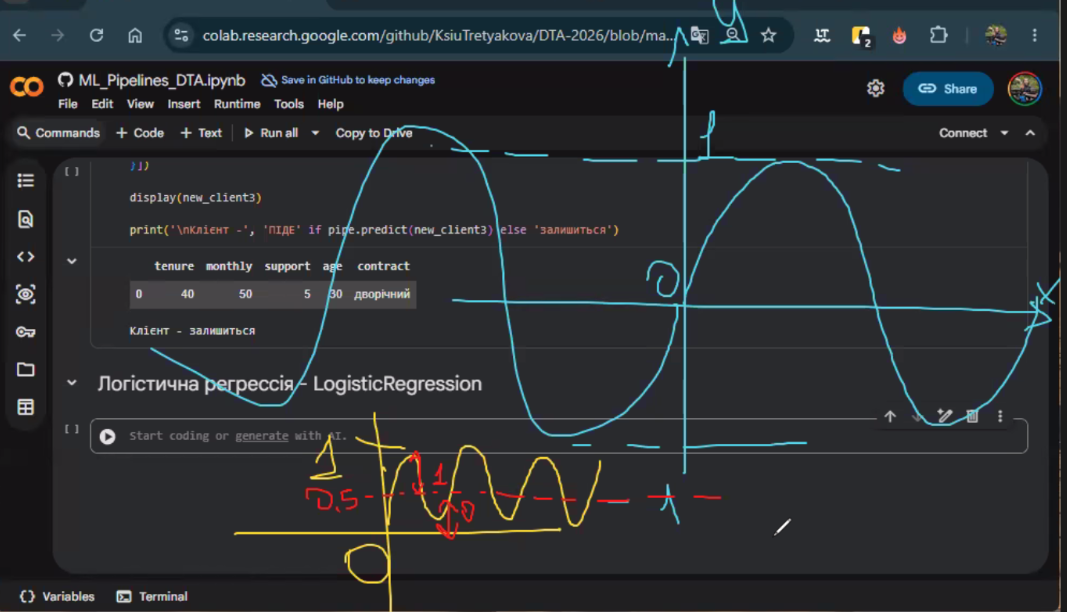

# Логістична регресія (Logistic Regression)

## Чому недостатньо лінійної регресії?

Лінійна регресія використовується для прогнозування **неперервних числових значень**. Вона описує залежність між ознаками та цільовою змінною у вигляді прямої лінії.

Однак для задач класифікації цільова змінна містить лише окремі класи (наприклад, **0** або **1**). У такому випадку звичайна лінійна регресія може передбачати будь-які значення (наприклад, 1.7 або –0.4), які не можна безпосередньо інтерпретувати як клас.

Тому для задач бінарної класифікації використовується **логістична регресія**, яка перетворює результат лінійної моделі у ймовірність належності до одного з класів.

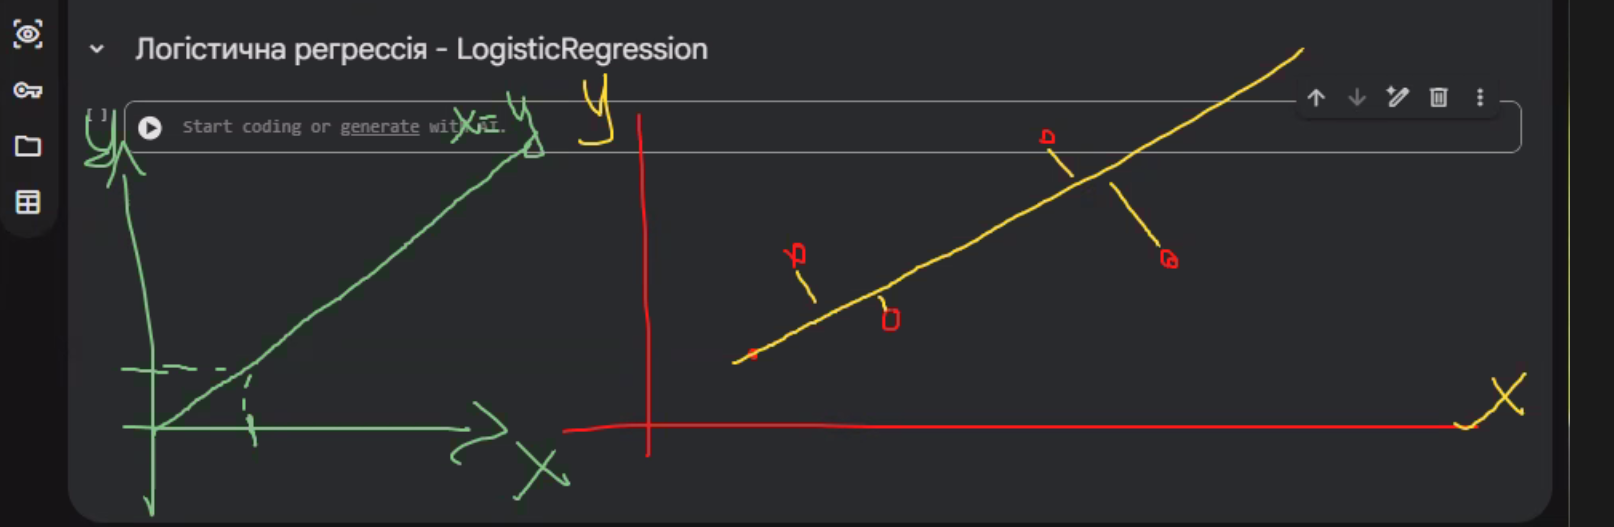

## Ймовірності, які повертає Logistic Regression

На відміну від більшості алгоритмів класифікації, Logistic Regression може повертати не лише прогнозований клас (`0` або `1`), а й **ймовірність належності об'єкта до кожного класу**.

Для цього використовується метод `predict_proba()`.

У цьому прикладі отримується ймовірність належності до класу **1** (відтік клієнта). Кожне значення знаходиться в діапазоні від **0 до 1**:

- значення, близькі до **0**, означають низьку ймовірність відтоку;
- значення, близькі до **1**, означають високу ймовірність відтоку.

Саме ці ймовірності надалі використовуються для прийняття рішення про те, до якого класу віднести кожного клієнта.

### Прийняття рішення на основі ймовірності

Метод `predict_proba()` повертає ймовірність належності кожного об'єкта до класу **1** (відтік клієнта). Проте для практичного використання необхідно отримати остаточний прогноз — **0** або **1**.

Метод `predict()` автоматично застосовує поріг **0.5**:

- якщо ймовірність ≥ 0.5 → прогнозується клас **1** («ПІДЕ»);
- якщо ймовірність < 0.5 → прогнозується клас **0** («залишиться»).

У цьому прикладі для перших п'яти клієнтів одночасно відображаються:
- вихідні характеристики;
- ймовірність відтоку;
- остаточне рішення моделі.

In [32]:
from sklearn.metrics import classification_report

# Ймовірність належності до класу 1 (відтік)
proba = pipe.predict_proba(X_test)[:, 1]

# Остаточний прогноз (0 або 1)
pred = pipe.predict(X_test)

# Формуємо приклад для перших п'яти клієнтів
demo = X_test.head().copy()

# Додаємо ймовірність відтоку
demo['proba(піде)'] = proba[:5].round(2)

# Додаємо текстове рішення моделі
demo['рішення (поріг 0.5)'] = np.where(
    pred[:5] == 1,
    'ПІДЕ',
    'залишиться'
)

# Виводимо результат
demo

,tenure,monthly,support,age,contract,proba(піде),рішення (поріг 0.5)
599,62,52.6,1,50,річний,0.06,залишиться
1236,61,42.9,3,60,місячний,0.27,залишиться
1452,49,77.1,0,18,місячний,0.27,залишиться
334,5,80.5,2,26,дворічний,0.66,ПІДЕ
123,42,16.1,3,52,місячний,0.35,залишиться


### Висновок

Модель Logistic Regression спочатку обчислює **ймовірність відтоку** для кожного клієнта, а потім автоматично перетворює її на остаточне рішення за допомогою порога **0.5**.

Наприклад:

- ймовірність **0.06** → клієнт **залишиться**;
- ймовірність **0.27** → клієнт **залишиться**;
- ймовірність **0.66** → клієнт **ПІДЕ**.

Таким чином, `predict()` є результатом застосування порогового значення до ймовірностей, отриманих методом `predict_proba()`.

### Аналіз коефіцієнтів моделі

Однією з переваг Logistic Regression є її інтерпретованість. Після навчання можна переглянути коефіцієнти моделі та оцінити вплив кожної ознаки на прогноз.

Для цього використовується:
- `named_steps['prep']` — доступ до блоку попередньої обробки даних (Pipeline);
- `get_feature_names_out()` — отримання назв усіх ознак після масштабування та One-Hot Encoding;
- `named_steps['model'].coef_` — отримання коефіцієнтів навченої моделі.

Кожному коефіцієнту відповідає певна ознака. Знак і величина коефіцієнта показують напрямок та силу її впливу на ймовірність відтоку клієнта.

### Аналіз впливу ознак на ризик відтоку

Після навчання Logistic Regression можна проаналізувати, які ознаки найбільше впливають на прогноз моделі.

Для цього отримуються:
- назви ознак після всіх перетворень Pipeline;
- коефіцієнти навченої моделі;
- таблиця, відсортована за абсолютним значенням коефіцієнтів.

Чим більший модуль коефіцієнта, тим сильніше відповідна ознака впливає на ризик відтоку клієнта.

In [34]:
# Отримуємо назви ознак після всіх перетворень Pipeline
feat_names = pipe.named_steps['prep'].get_feature_names_out()

# Отримуємо коефіцієнти навченої Logistic Regression
coefs = pipe.named_steps['model'].coef_[0]

# Формуємо таблицю для аналізу
coef_df = pd.DataFrame({
    'feature': feat_names,
    'coef': coefs
})

# Переглядаємо коефіцієнти
coef_df

,feature,coef
0,num__tenure,-1.009760
1,num__monthly,0.525213
2,num__support,0.554154
3,num__age,-0.019732
4,cat__contract_дворічний,-0.635490
5,cat__contract_місячний,0.829437
6,cat__contract_річний,-0.189502


### Висновок

Отримана таблиця показує силу та напрямок впливу кожної ознаки на прогноз Logistic Regression.

Інтерпретація коефіцієнтів:

- **додатний коефіцієнт (+)** — ознака підвищує ризик відтоку;
- **від'ємний коефіцієнт (-)** — ознака знижує ризик відтоку;
- **чим більший модуль коефіцієнта**, тим сильніше вплив ознаки на прогноз.

У цьому прикладі найбільший вплив мають:

- **`num_tenure (-1.01)`** — триваліший період користування послугами значно зменшує ризик відтоку;
- **`cat_contract_місячний (0.83)`** — місячний контракт підвищує ризик відтоку;
- **`cat_contract_дворічний (-0.64)`** — дворічний контракт зменшує ризик відтоку;
- **`num_support (0.55)`** — більша кількість звернень до служби підтримки пов'язана зі зростанням ризику відтоку;
- **`num_monthly (0.53)`** — вищий щомісячний платіж також підвищує ризик відтоку.

Після сортування за абсолютним значенням коефіцієнтів найважливіші фактори розташовані на початку таблиці, що значно спрощує інтерпретацію моделі.